# Machine Learning Final Proyect - Nopales
### David Villanueva Guzmán - U6110618
### Alvaro Cámara Guerra - U6110583

## CROSS VALIDATION 

### Import Required Libraries

In [1]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_train\Scripts\python.exe
2.9.1+cu128
True


In [2]:
import torch, kornia, platform
# Define device foor runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())
print(device)

Torch: 2.9.1+cu128
CUDA version in torch: 12.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9
cuda


In [3]:
!nvidia-smi

Fri Dec 19 17:09:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.05                 Driver Version: 577.05         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              4W /   97W |    3228MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# !pip install "numpy<2.0" --force-reinstall
# !pip install kornia
import warnings
warnings.filterwarnings("ignore")

In [5]:
# For data processing
# !pip install pandas
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the Dataset
Milan Dataset --

In [6]:
# Import Multiclass and Binary annotations
file_path_MC = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_multiclass.csv"
file_path_BIN = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_binary.csv"
# file_path_MC = "/home/udem09/ifros/machine-learning/annotations_multiclass.csv"
# file_path_BIN = "/home/udem09/ifros/machine-learning/annotations_binary.csv"

# Get dataframes of annotations
df_MC = pd.read_csv(file_path_MC)
df_MC.drop(columns=["Unnamed: 2", "Unnamed: 3"], inplace=True)

print(df_MC.head(10))

  file_prefix printError_physicalDefect
0  001_516_01                       0_0
1  001_516_02                       0_1
2  001_516_03                       0_0
3  001_516_04                       0_0
4  001_516_05                       0_0
5  001_516_06                       0_0
6  001_516_07                       0_0
7  001_516_08                       0_0
8  001_516_09                       0_0
9  001_516_10                       1_0


#### Data Preprocessing

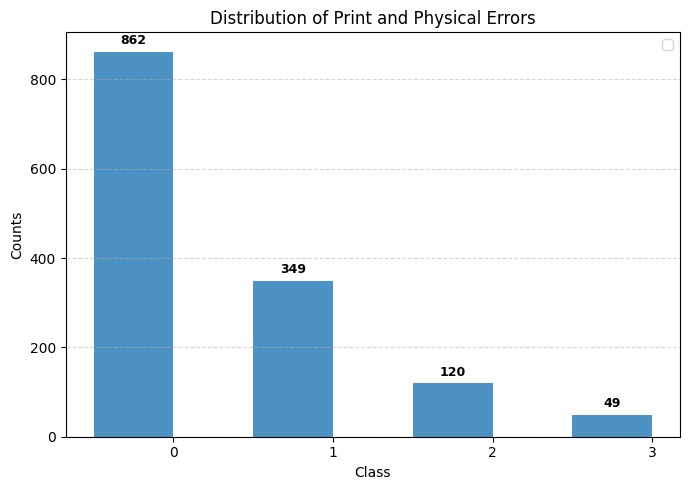

     file_prefix printError_physicalDefect  printError_physicalDefect_int
0     001_516_01                       0_0                              0
1     001_516_02                       0_1                              1
2     001_516_03                       0_0                              0
3     001_516_04                       0_0                              0
4     001_516_05                       0_0                              0
...          ...                       ...                            ...
1375  002_100_11                       0_1                              1
1376  002_100_12                       0_0                              0
1377  002_100_13                       0_0                              0
1378  002_100_14                       0_0                              0
1379  002_100_15                       1_0                              2

[1380 rows x 3 columns]


In [7]:
mapping = {
    "0_0": 0,
    "0_1": 1,
    "1_0": 2,
    "1_1": 3
}

df_MC["printError_physicalDefect_int"] = df_MC["printError_physicalDefect"].map(mapping)

# Count occurrences of each class
print_counts = df_MC["printError_physicalDefect_int"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_MC)

### Binary annotations

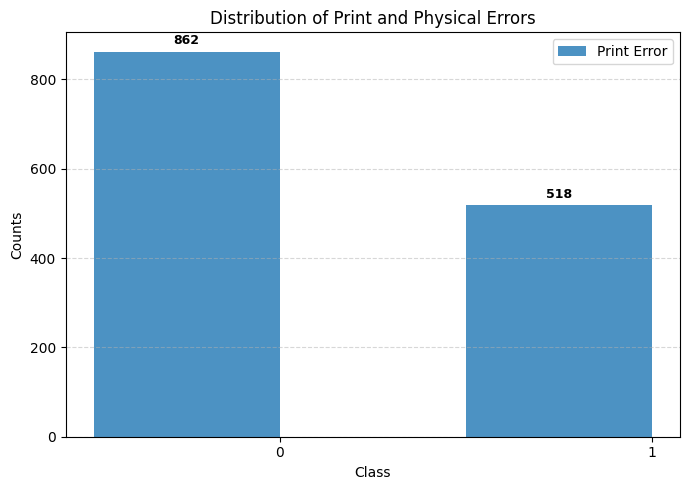

In [8]:
# Lista de strings a buscar en el nombre de la imagen

# Filtrar solo filas donde la segunda columna sea exactamente '0_0'
df_MC["binary"] = (df_MC["printError_physicalDefect_int"] != 0).astype(int)

# Count occurrences of each class
print_counts = df_MC["binary"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, label='Print Error', color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Data reduction

#### Unzip images inside google drive

In [9]:
# extract_path = "/home/udem09/ifros/machine-learning/arrays"
# extract_path = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/arrays'
extract_path = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\drive-download-20251113T114126Z-1-001\arrays"

#### Define NPYImageDataset class to load the images

In [10]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np

class NPYImageDataset(Dataset):
    def __init__(self, root_dir, names, labels, transform=None):
        """
        root_dir : Folder with .npy files
        names    : List like ['003_045_012', '002_047_12', ...]
        labels   : Array-like with class labels aligned with 'names'
        transform: torchvision transform
        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)                          # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label


### Define all the labels and all the images names

In [11]:
all_names = df_MC["file_prefix"].values      # list of .npy filenames
all_labels_list = df_MC["binary"].values       # 0 / 1 labels

## Save some images to test the model and ensure consistency with pytorch + ONNX

In [12]:
from sklearn.model_selection import train_test_split

# All indices as ints
indices = np.arange(len(all_names))

# dataset + pseudo-test
dataset_idx, test_idx = train_test_split(
    indices,
    test_size=0.05,
    stratify=all_labels_list,
    random_state=42
)

In [13]:
# Apply split to names and labels
dataset_names = all_names[dataset_idx]
test_names   = all_names[test_idx]

dataset_labels = all_labels_list[dataset_idx]
test_labels   = all_labels_list[test_idx]

In [14]:
print(len(dataset_names))
print(len(all_labels_list))

1311
1380


#### Data transforming

In [15]:
import torchvision.transforms.v2 as transforms
import torch
import kornia.augmentation as K

def scale_image(x):
    return x / 255.0

data_transform = transforms.Compose([
    # Input comes as (C,H,W) torch tensor from NPY
    # Scale to [0,1]
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    # Normalize all 6 channels
    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

## Data augmentation

In [16]:
kornia_augment = torch.nn.Sequential(
    # Flips (safe for defects)
    K.RandomHorizontalFlip(p=0.5),
    K.RandomVerticalFlip(p=0.3),
    
    # Minimal geometric
    K.RandomRotation(degrees=5.0, p=0.3),
    K.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.98, 1.02), p=0.3),
    
    # Strong photometric (main augmentation)
    K.RandomBrightness((0.8, 1.2), p=0.4),
    K.RandomContrast((0.8, 1.2), p=0.4),
    # K.RandomGamma((0.85, 1.15), p=0.3),
    
    # Minimal noise and erasing
    K.RandomGaussianNoise(std=0.01, p=0.2),
    K.RandomErasing(scale=(0.01, 0.05), p=0.2),
)

In [17]:
dataset = NPYImageDataset(
    root_dir=extract_path,
    names=dataset_names,
    labels=dataset_labels,
    transform=None
)

test_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=test_names,
    labels=test_names,
    transform=None
)

#### Visuazlie a sample and the whole dataset

In [18]:
import os
import numpy as np

bad_files = []
good = 0

for f in os.listdir(extract_path):
    if not f.lower().endswith(".npy"):
        continue

    full = os.path.join(extract_path, f)

    try:
        arr = np.load(full)
        _ = arr.shape  # force read
        good += 1
    except Exception as e:
        print("❌ Bad file:", full)
        print("   Error:", repr(e))
        bad_files.append(full)

print("\n✅ Good files:", good)
print("❌ Bad files:", len(bad_files))



✅ Good files: 1380
❌ Bad files: 0


label =  tensor(1)
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 6, 310, 310])
Label: tensor(1)


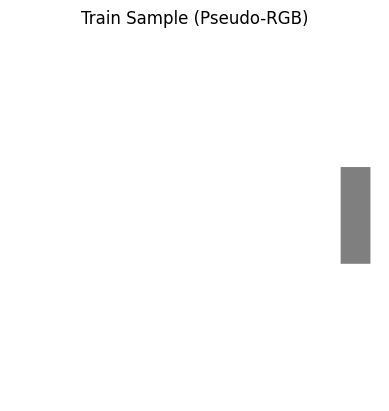

In [19]:
# Visualize one sample directly from the DATASET 
import matplotlib.pyplot as plt

# Get one raw sample from the dataset
visualize_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=dataset_names,
    labels=dataset_labels,
    transform=data_transform
)

img, label = dataset[0]
print("label = ",label)
img = kornia_augment(img)

print("Type:", type(img))
print("Shape:", img.shape)      # (1, 6, H, W)
print("Label:", label)

# Undo normalization for visualization
img_vis = img[0, :3] * 0.5 + 0.5   # Take first 3 channels from the first image in batch as pseudo-RGB
img_vis = img_vis.clamp(0, 1)  

# Show image
plt.imshow(img_vis.permute(1, 2, 0))
plt.title("Train Sample (Pseudo-RGB)")
plt.axis("off")
plt.show()

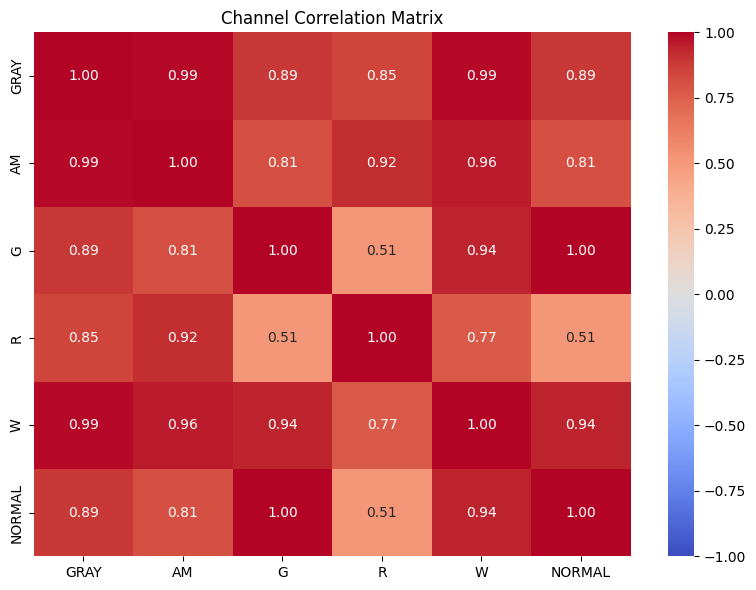


Correlation Matrix:
[[1.         0.98780115 0.88815673 0.84716931 0.99106323 0.89056716]
 [0.98780115 1.         0.80766149 0.9164272  0.95878811 0.81027992]
 [0.88815673 0.80766149 1.         0.50868047 0.94054729 0.99928951]
 [0.84716931 0.9164272  0.50868047 1.         0.76967062 0.51463938]
 [0.99106323 0.95878811 0.94054729 0.76967062 1.         0.94205373]
 [0.89056716 0.81027992 0.99928951 0.51463938 0.94205373 1.        ]]

⚠️ Highly correlated channel pairs (>0.85):
  GRAY <-> AM: 0.988
  GRAY <-> G: 0.888
  GRAY <-> W: 0.991
  GRAY <-> NORMAL: 0.891
  AM <-> R: 0.916
  AM <-> W: 0.959
  G <-> W: 0.941
  G <-> NORMAL: 0.999
  W <-> NORMAL: 0.942


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_channel_correlation(dataset):
    """Check if channels are redundant"""
    # Sample 100 random images
    sample_images = []
    for i in np.random.choice(len(dataset), 100, replace=False):
        img, _ = dataset[i]  # [6, H, W]
        sample_images.append(img.numpy())
    
    sample_images = np.array(sample_images)  # [100, 6, H, W]
    
    # Flatten spatial dimensions
    samples_flat = sample_images.reshape(100, 6, -1).mean(axis=2)  # [100, 6]
    
    # Correlation matrix
    corr_matrix = np.corrcoef(samples_flat.T)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
                xticklabels=['GRAY', 'AM', 'G', 'R', 'W', 'NORMAL'],
                yticklabels=['GRAY', 'AM', 'G', 'R', 'W', 'NORMAL'],
                cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Channel Correlation Matrix')
    plt.tight_layout()
    plt.savefig('channel_correlation.png', dpi=150)
    plt.show()
    
    print("\nCorrelation Matrix:")
    print(corr_matrix)
    
    # Check for highly correlated pairs (> 0.85)
    high_corr = np.where((corr_matrix > 0.85) & (corr_matrix < 1.0))
    if len(high_corr[0]) > 0:
        print("\n⚠️ Highly correlated channel pairs (>0.85):")
        for i, j in zip(high_corr[0], high_corr[1]):
            if i < j:
                channels = ['GRAY', 'AM', 'G', 'R', 'W', 'NORMAL']
                print(f"  {channels[i]} <-> {channels[j]}: {corr_matrix[i,j]:.3f}")
    
    return corr_matrix

# Run it
corr = analyze_channel_correlation(dataset)

### Setting the Device

### Train and Validation Fucntions

In [21]:
#train function
from sklearn.metrics import average_precision_score, f1_score
import torch.nn.functional as F
import numpy as np

def Train(model, train_loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for i, (images, labels) in enumerate(train_loader):


        # Move augmented batch to GPU for training
        images = images.to(device)
        labels = labels.to(device)

        # Data augmentation with kornia in the GPU 
        images = kornia_augment(images)

        # Initialize backpropagation and optimization
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Backpropagation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Convert logits → probability of positive class
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Compute AUC-PR for the full epoch
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # AUC-PR
    if len(np.unique(all_labels)) > 1:
        auc_pr = average_precision_score(all_labels, all_probs)
    else:
        auc_pr = 0.0

    # Average loss
    avg_loss = running_loss / len(train_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

#validation function
def Validate(model, val_loader, criterion):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits → probability of positive class
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

        # AUC-PR
    if len(np.unique(all_labels)) > 1:
        auc_pr = average_precision_score(all_labels, all_probs)
    else:
        auc_pr = 0.0

    avg_loss = running_loss / len(val_loader)

    # ----- FIND BEST THRESHOLD FOR F1 -----
    thresholds = np.linspace(0.0, 1.0, 200)
    f1_scores = [
        f1_score(all_labels, (all_probs >= t).astype(int)) 
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return avg_loss, auc_pr, best_f1, best_threshold

### Import the model 

In [22]:
import torch
import torch.nn as nn
import torchvision.models as models


def build_model_resnet34(
    head,
    dropout_rate=0.35,
    frozen_layers=(""), # No initial frozen layer
    pretrained=True
  ):
    """
    Creates a fresh ResNet34 with:
    - ImageNet pretrained weights
    - 6-channel input
    - Custom MLP head
    - Selective layer freezing

    Safe to call once per CV fold.
    """

    # Load the model RESNET34
    model = models.resnet34(
        weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None,
        progress=False
    )

    # Adapts the first layer
    old_conv = model.conv1
    new_conv = nn.Conv2d(
        in_channels=6,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias
    )

    with torch.no_grad():
        # Copy RGB weights
        new_conv.weight[:, :3] = old_conv.weight
        # Initialize extra channels sensibly
        new_conv.weight[:, 3:] = old_conv.weight.clone()

    model.conv1 = new_conv

    # Freeze selected layers
    for name, param in model.named_parameters():
        param.requires_grad = not name.startswith(frozen_layers)

    # Adapt the FC layer
    model.fc = head
    # Return the virgin model 
    return model

In [30]:
def build_model_resnet18(
    head,
    dropout_rate=0.35,
    frozen_layers=(""), # No initial frozen layer
    pretrained=True,
    n_channels = 6,
  ):
    """
    Creates a fresh ResNet34 with:
    - ImageNet pretrained weights
    - 6-channel input
    - Custom MLP head
    - Selective layer freezing

    Safe to call once per CV fold.
    """

    # Load the model RESNET18
    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    )

    # Adapts the first layer
    old_conv = model.conv1
    new_conv = nn.Conv2d(
        in_channels=n_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias
    )

    # Only redefine the first layer if the number of input channels is different than 3 (original input size)
    with torch.no_grad():
        if n_channels == 3:
            # Direct copy for RGB
            new_conv.weight = old_conv.weight
            
        elif n_channels < 3:
            # Fewer than 3 channels: use subset of RGB weights
            new_conv.weight[:, :n_channels] = old_conv.weight[:, :n_channels]
            
        else:
            # More than 3 channels: replicate RGB weights
            # Repeat RGB pattern and use mean for remaining
            
            # Copy first 3 channels (RGB)
            new_conv.weight[:, :3] = old_conv.weight
            
            # For remaining channels, use mean of RGB weights
            rgb_mean = old_conv.weight.mean(dim=1, keepdim=True)  # [64, 1, 7, 7]
            
            for i in range(3, n_channels):
                new_conv.weight[:, i:i+1] = rgb_mean
    model.conv1 = new_conv

    # Freeze selected layers
    for name, param in model.named_parameters():
        param.requires_grad = not name.startswith(frozen_layers)

    # Adapt the FC layer
    model.fc = head

    # Return the virgin model 
    return model

## Criterion and optimizer

In [31]:
# FocalLoss alternative as criterion
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss para clasificación binaria/multiclase con desbalance.

    Parámetros:
    -----------
    alpha : tensor o None
        Peso para cada clase. Ej: [0.3, 0.7] da más peso a clase 1
    gamma : float
        Factor de enfoque. Típicamente 2.0
        - gamma=0 equivale a CrossEntropyLoss
        - gamma>0 reduce la pérdida para ejemplos bien clasificados
    label_smoothing : float
        Suavizado de etiquetas (0.0 a 0.2 típicamente)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # será un tensor en GPU
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: logits del modelo, shape (N, C) donde C=num_classes
        targets: etiquetas, shape (N,) con valores 0 o 1
        """
        # Calcular log-softmax para estabilidad numérica
        log_probs = F.log_softmax(inputs, dim=1)

        # Obtener log_prob de la clase correcta para cada muestra
        # targets.unsqueeze(1) -> (N, 1)
        # gather selecciona el log_prob correspondiente a la clase correcta
        ce_loss = F.nll_loss(log_probs, targets, reduction='none')

        # Probabilidad de la clase correcta
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal weight: (1 - pt)^gamma
        focal_weight = (1 - pt) ** self.gamma

        # Aplicar focal weight
        focal_loss = focal_weight * ce_loss

        # Aplicar alpha (peso por clase) si está definido
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        # Reducción
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [32]:
import torch
import torch.nn as nn

class AsymmetricLoss(nn.Module):
    """
    Asymmetric Loss for imbalanced classification.
    
    Treats positives and negatives differently with asymmetric focusing.
    Better than Focal Loss for datasets with moderate imbalance.
    
    Parameters:
    -----------
    gamma_neg : float
        Focusing parameter for negative class (non-defective)
        Higher = focus more on hard negatives
    gamma_pos : float
        Focusing parameter for positive class (defective)
        Usually lower than gamma_neg
    clip : float
        Clipping value to prevent overconfidence on negatives
        Helps reduce false negatives
    reduction : str
        'mean' or 'sum'
    """
    def __init__(self, gamma_neg=2, gamma_pos=1, clip=0.05, reduction='mean'):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits: raw model outputs, shape (N, 2) for binary classification
        targets: ground truth labels, shape (N,) with values 0 or 1
        """
        # Get probabilities from logits
        probs = torch.softmax(logits, dim=1)
        
        # Probabilities for positive class (defective)
        pos_probs = probs[:, 1]  # P(class=1)
        neg_probs = probs[:, 0]  # P(class=0)
        
        # Convert targets to float for calculations
        targets_float = targets.float()
        
        # Asymmetric clipping on negative class
        # This prevents the model from being overconfident on negatives
        neg_probs = (neg_probs + self.clip).clamp(max=1.0)
        
        # Calculate cross-entropy components
        pos_loss = targets_float * torch.log(pos_probs.clamp(min=1e-8))
        neg_loss = (1 - targets_float) * torch.log(neg_probs.clamp(min=1e-8))
        
        # Asymmetric focusing: weight by (1-p)^gamma
        # Focus more on hard examples (low probability for correct class)
        pos_weight = ((1 - pos_probs) ** self.gamma_pos) * targets_float
        neg_weight = ((1 - neg_probs) ** self.gamma_neg) * (1 - targets_float)
        
        # Combine losses with asymmetric weighting
        loss = -(pos_loss * pos_weight + neg_loss * neg_weight)
        
        # Reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

## Freeze functions and optimizer builder

In [33]:
def apply_freezing(model, layer_groups: list[str], layers_to_modify: list[str], freeze_flag: bool):
    """
    freeze_flag: True → freeze layers, False → unfreeze layers
    layers_to_modify: list of keys from layer_groups,
    """

    target_substrings = []
    for key in layers_to_modify:
        target_substrings += layer_groups[key]

    for name, module in model.named_modules():
        if any(substr in name for substr in target_substrings):
            for param in module.parameters():
                param.requires_grad = (not freeze_flag)  # True→freeze means requires_grad=False

def build_optimizer(model, lr: float, wd: float,
                    optimizer_type: str = "AdamW"):
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    match optimizer_type:
        case "AdamW":
            return torch.optim.AdamW(
                trainable_params,
                lr=lr,
                weight_decay=wd
            )
        case "Adam":
            return torch.optim.Adam(
                trainable_params,
                lr=lr,
                weight_decay=wd
            )
        case _:
            raise "Wrong optimizer type"
        
# Optimizer and Criterion
def compute_class_stats_from_loader(loader):
    total_per_class = torch.zeros(2)

    for _, labels in loader:
        for c in [0, 1]:
            total_per_class[c] += (labels == c).sum()

    N0 = int(total_per_class[0].item())  # non-defective
    N1 = int(total_per_class[1].item())  # defective

    return N0, N1

In [34]:
num_epochs = 200
patience = 15
min_delta = 2e-2

best_val_aucpr = 0.0
epochs_no_improve = 0
best_model_state = None

### Train the model with cross validation

In [35]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
import numpy as np

# Early stopping parameters
patience = 25
min_delta = 3e-3
dropout_rate = 0.5
optimizer_type = "AdamW"

k_folds = 5
n_repeats = 3
skf = StratifiedKFold(n_splits=k_folds, 
                              shuffle=True,
                            #   n_repeats=n_repeats, 
                              random_state=42)

labels = np.array(dataset.labels)

# Parameters for the criterion 
weight_decay = 2e-3
alpha = torch.tensor([0.35, 0.65]).to(device)  # suma = 1.0

# Parameters for dataset
batch_size = 16

# Layers of Resnet34
layer_groups = {
    "conv1": ["conv1", "bn1"],
    "layer1": ["layer1"],
    "layer2": ["layer2"],
    "layer3": ["layer3"],
    "layer4": ["layer4"],
    "head":   ["fc"],   # classifier
}

model_head = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(512, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(dropout_rate * 0.5),
        nn.Linear(64, 2)
    )

# Dynamically freeze layers
freeze_schedule = [
    (20, True, ['layer1', 'layer2', 'layer3', 'layer4'], 8e-5),   # Only train head and conv1
    (100, False, ['layer1', 'layer2', 'layer3', 'layer4'], 3e-5),  # Train all
]

In [36]:
from torch.utils.data import DataLoader

fold_results_aucpr = []
fold_results_f1 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n=== Fold {fold+1}/{k_folds} ===")

    # Subsets
    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset   = torch.utils.data.Subset(dataset, val_idx)

    # Apply transforms
    train_subset.dataset.transform = data_transform
    val_subset.dataset.transform   = data_transform

    # DataLoaders
    train_loader = DataLoader(train_subset, 
                              batch_size=batch_size, 
                              pin_memory=True, 
                              shuffle=True,
                              drop_last=False,
                              num_workers= 0
                              )
    val_loader   = DataLoader(val_subset, 
                              batch_size=batch_size, 
                              pin_memory=True, 
                              shuffle=False,
                              num_workers= 0
                              )

    # Fresh Model 
    k_model = build_model_resnet18(head=model_head, 
                                   dropout_rate=dropout_rate).to(device)

    # Criterion
    # CrossEntropyLoss
    N0, N1 = compute_class_stats_from_loader(train_loader) # Get weights from the actual train loader

    # Calculate the weights
    beta = 0.999
    w0 = (1 - beta) / (1 - beta**N0)
    w1 = (1 - beta) / (1 - beta**N1)

    weights = torch.tensor([w0, w1]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.035)

    # FocalLoss
    # criterion = FocalLoss(
    #     alpha=alpha,
    #     gamma=2.0,
    #     label_smoothing=0.0
    # )

    # Early stopping variables
    best_val_aucpr = 0.0
    best_val_f1 = 0.0
    best_train_aucpr = 0.0
    best_train_f1 = 0.0
    best_epoch = 0
    epochs_no_improve = 0
    global_epoch = 0

    # repeat_num = fold // 5 + 1
    # fold_num = fold % 5 + 1

    # print(f"\n=== Repeat {repeat_num}/3 | Fold {fold_num}/5 ===")

    for phase_id, (phase_epochs, freeze_flag, layers_to_modify, lr) in enumerate(freeze_schedule):
        print(
            f"\n  Phase {phase_id+1}: "
            f"{'Freeze' if freeze_flag else 'Unfreeze'} {layers_to_modify} | "
            f"epochs={phase_epochs} | lr={lr}"
        )

        # Apply freezing
        apply_freezing(k_model, layer_groups, layers_to_modify, freeze_flag)

        # Restart optimizer
        optimizer = build_optimizer(k_model, lr, weight_decay, optimizer_type=optimizer_type)

        # Cosine scheduler (per phase)
        # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        #     optimizer, T_max=phase_epochs
        # )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=15,
            T_mult=2,
            eta_min=1e-7
        )

        # Training loop (phase)
        for epoch in range(phase_epochs):
            global_epoch += 1

            train_loss, train_aucpr, train_f1 = Train(
                k_model, train_loader, optimizer, criterion
            )

            val_loss, val_aucpr, val_f1, val_best_th = Validate(
                k_model, val_loader, criterion
            )

            scheduler.step()

            # ---- EARLY STOPPING ----
            if val_aucpr > best_val_aucpr + min_delta:
                best_val_aucpr = val_aucpr
                best_val_f1 = val_f1
                best_train_aucpr = train_aucpr
                best_train_f1 = train_f1
                best_epoch = global_epoch
                epochs_no_improve = 0
                best_model_state = k_model.state_dict()
            else:
                epochs_no_improve += 1

            # Light progress print
            print(
                f"    Epoch {global_epoch:03d} | "
                f"Train AUC-PR={train_aucpr:.4f} | "
                f"Val AUC-PR={val_aucpr:.4f} | "
                f"NoImprove={epochs_no_improve}/{patience}",
            )

            if epochs_no_improve >= patience:
                print("\n    Early stopping triggered.")
                break

        if epochs_no_improve >= patience:
            break

    # Fold summary
    fold_results_aucpr.append(best_val_aucpr)
    fold_results_f1.append(best_val_f1)

    print(
        f"\nFold {fold+1} DONE | "
        f"Epochs={best_epoch} | "
        f"Train AUC-PR={best_train_aucpr:.4f} | "
        f"Val AUC-PR={best_val_aucpr:.4f} | "
        f"Val F1={best_val_f1:.4f}"
    )


=== Fold 1/5 ===

  Phase 1: Freeze ['layer1', 'layer2', 'layer3', 'layer4'] | epochs=20 | lr=8e-05
    Epoch 001 | Train AUC-PR=0.3895 | Val AUC-PR=0.4905 | NoImprove=0/25
    Epoch 002 | Train AUC-PR=0.3829 | Val AUC-PR=0.4957 | NoImprove=0/25
    Epoch 003 | Train AUC-PR=0.4137 | Val AUC-PR=0.4866 | NoImprove=1/25
    Epoch 004 | Train AUC-PR=0.4020 | Val AUC-PR=0.5070 | NoImprove=0/25
    Epoch 005 | Train AUC-PR=0.4103 | Val AUC-PR=0.5418 | NoImprove=0/25
    Epoch 006 | Train AUC-PR=0.3742 | Val AUC-PR=0.5150 | NoImprove=1/25
    Epoch 007 | Train AUC-PR=0.4160 | Val AUC-PR=0.5141 | NoImprove=2/25
    Epoch 008 | Train AUC-PR=0.4125 | Val AUC-PR=0.5286 | NoImprove=3/25
    Epoch 009 | Train AUC-PR=0.4038 | Val AUC-PR=0.5421 | NoImprove=4/25
    Epoch 010 | Train AUC-PR=0.3947 | Val AUC-PR=0.5290 | NoImprove=5/25
    Epoch 011 | Train AUC-PR=0.4229 | Val AUC-PR=0.5267 | NoImprove=6/25
    Epoch 012 | Train AUC-PR=0.4065 | Val AUC-PR=0.5337 | NoImprove=7/25
    Epoch 013 | Train A

In [37]:
fold_results_aucpr = np.array(fold_results_aucpr)
fold_results_f1 = np.array(fold_results_f1)

print(f"\nCV AUC-PR: {fold_results_aucpr.mean():.4f} ± {fold_results_aucpr.std():.4f}")
print(f"\nCV F1 score: {fold_results_f1.mean():.4f} ± {fold_results_f1.std():.4f}")


CV AUC-PR: 0.8078 ± 0.0620

CV F1 score: 0.7238 ± 0.0531
